# Boardgame EDA

In [15]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Acceleration? {device}")

Acceleration? cuda


In [4]:
import pandas as pd

# Assuming your uploaded file is named 'your_large_data.csv'
# If you used files.upload(), the file will be in the current directory
# You might need to adjust the file path if it's in a subfolder
file_path = '/content/drive/MyDrive/Colab Notebooks/games_detailed_info2025.csv'

try:
    df = pd.read_csv(file_path)
    print(f"DataFrame loaded successfully from {file_path}. Here are the first few rows:")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it's uploaded to your Colab environment.")
except Exception as e:
    print(f"An error occurred while loading the CSV file: {e}")

DataFrame loaded successfully from /content/drive/MyDrive/Colab Notebooks/games_detailed_info2025.csv. Here are the first few rows:


,id,name,description,boardgamecategory,boardgamemechanic,boardgamedesigner,usersrated,rating,bayes_rating,num_comments,playtime,min_playtime,max_playtime
0,13,CATAN,"In CATAN (formerly The Settlers of Catan), pla...","['Economic', 'Negotiation']","['Chaining', 'Dice Rolling', 'Hexagon Grid', '...",['Klaus Teuber'],132477,7.09526,6.91526,22600,120,60,120
1,822,Carcassonne,Carcassonne is a tile placement game in which ...,"['Medieval', 'Territory Building']","['Area Majority / Influence', 'Enclosure', 'Ma...",['Klaus-Jürgen Wrede'],131182,7.41145,7.29556,22150,45,30,45
2,30549,Pandemic,"In Pandemic, several virulent diseases have br...",['Medical'],"['Action Points', 'Cooperative Game', 'Hand Ma...",['Matt Leacock'],128935,7.52913,7.42156,19897,45,45,45
3,68448,7 Wonders,You are the leader of one of the 7 great citie...,"['Ancient', 'Card Game', 'City Building', 'Civ...","['Closed Drafting', 'Hand Management', 'Neighb...",['Antoine Bauza'],107506,7.67463,7.56393,16690,30,30,30
4,167791,Terraforming Mars,"In the 2400s, mankind begins to terraform the ...","['Economic', 'Environmental', 'Industry / Manu...","['Closed Drafting', 'Contracts', 'End Game Bon...",['Jacob Fryxelius'],103923,8.35266,8.20450,14696,120,120,120


### Data Preprocessing for Tabular Data

This section preprocesses the `csv_data` to make it suitable for a neural network. It handles categorical features by one-hot encoding and scales numerical features. The `average` column is set as the target variable.

In [5]:
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.model_selection import train_test_split

# Drop columns that are not directly usable as features or have high cardinality
columns_to_drop = ['id', 'name', 'description', 'boardgamedesigner']
df_processed = df.drop(columns=columns_to_drop, errors='ignore')

# Handle 'boardgamecategory' and 'boardgamemechanic' (list-like strings)
def parse_list_string(s):
    if isinstance(s, str):
        try:
            # Evaluate string as a Python list and handle potential single quotes
            return eval(s.replace("'", '"'))
        except (SyntaxError, TypeError):
            return []
    return []

df_processed['boardgamecategory_list'] = df_processed['boardgamecategory'].apply(parse_list_string)
df_processed['boardgamemechanic_list'] = df_processed['boardgamemechanic'].apply(parse_list_string)

# Use MultiLabelBinarizer for one-hot encoding of these list-like columns
mlb_category = MultiLabelBinarizer()
category_features = mlb_category.fit_transform(df_processed['boardgamecategory_list'])
category_df = pd.DataFrame(category_features, columns=[f'category_{c}' for c in mlb_category.classes_], index=df_processed.index)

mlb_mechanic = MultiLabelBinarizer()
mechanic_features = mlb_mechanic.fit_transform(df_processed['boardgamemechanic_list'])
mechanic_df = pd.DataFrame(mechanic_features, columns=[f'mechanic_{m}' for m in mlb_mechanic.classes_], index=df_processed.index)

# Drop original list-like columns and add one-hot encoded ones
df_processed = df_processed.drop(columns=['boardgamecategory', 'boardgamemechanic', 'boardgamecategory_list', 'boardgamemechanic_list'], errors='ignore')
df_processed = pd.concat([df_processed, category_df, mechanic_df], axis=1)

# Separate features (X) and target (y)
X = df_processed.drop(columns=['rating'])
y = df_processed['rating']

# Handle missing numerical values (fill with mean)
numerical_cols = X.select_dtypes(include=np.number).columns
for col in numerical_cols:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].mean())

# Scale numerical features
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Convert to PyTorch tensors
X_tensor = torch.tensor(X.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1) # unsqueeze for regression output

# Determine input features for the model
input_features = X_tensor.shape[1]

print(f"Number of input features: {input_features}")
print(f"Shape of X_tensor: {X_tensor.shape}")
print(f"Shape of y_tensor: {y_tensor.shape}")

Number of input features: 280
Shape of X_tensor: torch.Size([27780, 280])
Shape of y_tensor: torch.Size([27780, 1])


In [6]:
# Summary of Features Used and Dropped

print("--- Feature Engineering Summary ---")

# 1. Dropped Columns
print(f"\nColumns Dropped (high cardinality or metadata):")
print(columns_to_drop)

# 2. Used Features
print(f"\nTotal Input Features: {input_features}")

# Break down used features
numerical_features = numerical_cols.tolist()
category_list = [c for c in X.columns if c.startswith('category_')]
mechanic_list = [m for m in X.columns if m.startswith('mechanic_')]

print(f"- Numerical Features ({len(numerical_features)}): {numerical_features}")
print(f"- One-Hot Categories ({len(category_list)}): {category_list[:5]}... (and {len(category_list)-5} more)")
print(f"- One-Hot Mechanics ({len(mechanic_list)}): {mechanic_list[:5]}... (and {len(mechanic_list)-5} more)")

--- Feature Engineering Summary ---

Columns Dropped (high cardinality or metadata):
['id', 'name', 'description', 'boardgamedesigner']

Total Input Features: 280
- Numerical Features (280): ['usersrated', 'bayes_rating', 'num_comments', 'playtime', 'min_playtime', 'max_playtime', 'category_Abstract Strategy', 'category_Action / Dexterity', 'category_Adventure', 'category_Age of Reason', 'category_American Civil War', 'category_American Indian Wars', 'category_American Revolutionary War', 'category_American West', 'category_Ancient', 'category_Animals', 'category_Arabian', 'category_Aviation / Flight', 'category_Bluffing', 'category_Book', 'category_Card Game', 'category_City Building', 'category_Civil War', 'category_Civilization', 'category_Collectible Components', 'category_Comic Book / Strip', 'category_Deduction', 'category_Dice', 'category_Economic', 'category_Educational', 'category_Electronic', 'category_Environmental', 'category_Expansion for Base-game', 'category_Exploration'

In [7]:
from torch.utils.data import DataLoader, TensorDataset

# Create a TensorDataset from the preprocessed tensors
full_dataset = TensorDataset(X_tensor, y_tensor)

# Define split sizes
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
validation_size = int(0.1 * total_size)
test_size = total_size - train_size - validation_size

# Ensure non-negative sizes in case of small datasets
train_size = max(0, train_size)
validation_size = max(0, validation_size)
test_size = max(0, total_size - train_size - validation_size)

# Handle the case where total_size is very small and splits might be 0
# Distribute remaining samples if any exist due to rounding
if train_size + validation_size + test_size < total_size:
    train_size += (total_size - (train_size + validation_size + test_size))

# Split the dataset into training, validation, and test sets
train_dataset, validation_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, validation_size, test_size]
)

# Create DataLoader instances with a larger batch size
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Neural Nets

In [8]:
class BaselineNet(nn.Module):
    def __init__(self, input_features, dropout_rate=0.3):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_features, 512),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.model(x)

In [9]:
class DeepNet(nn.Module):
    def __init__(self, input_features, dropout_rate=0.3):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),

            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x)

## Utilities

In [10]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()

    running_loss, total = 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = loss_fn(predictions, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        total += y_batch.size(0)

    return running_loss / total

In [11]:
def evaluate(model, loader, loss_fn, device):
    model.eval()
    running_loss, total = 0, 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            predictions = model(X_batch)
            loss = loss_fn(predictions, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            total += y_batch.size(0)

    return running_loss / total

In [12]:
import copy

def fit(model, train_loader, val_loader, loss_fn, optimizer, device, epochs=10, patience=5):
    history = {
        "train_loss": [],
        "val_loss": []
    }

    model.to(device)
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    early_stop_count = 0

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val_loss = evaluate(model, val_loader, loss_fn, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f'Epoch: {epoch + 1}: Train loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

        # Early Stopping Logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            early_stop_count = 0
        else:
            early_stop_count += 1
            if early_stop_count >= patience:
                print(f"Early stopping triggered after {epoch + 1} epochs.")
                break

    # Load best model weights before returning
    model.load_state_dict(best_model_wts)
    return history

In [13]:
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.plot(epochs, history['train_loss'], label = 'Train Loss')
    plt.plot(epochs, history['val_loss'], label = 'Val Loss')
    plt.legend()
    plt.title('Loss curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()

## Baseline NN training

Epoch: 1: Train loss: 0.7071, Val Loss: 0.2679
Epoch: 2: Train loss: 0.3431, Val Loss: 0.2550
Epoch: 3: Train loss: 0.3146, Val Loss: 0.2540
Epoch: 4: Train loss: 0.3062, Val Loss: 0.2496
Epoch: 5: Train loss: 0.2994, Val Loss: 0.2651
Epoch: 6: Train loss: 0.2824, Val Loss: 0.2437
Epoch: 7: Train loss: 0.2775, Val Loss: 0.2285
Epoch: 8: Train loss: 0.2661, Val Loss: 0.2225
Epoch: 9: Train loss: 0.2632, Val Loss: 0.2202
Epoch: 10: Train loss: 0.2592, Val Loss: 0.2290
Epoch: 11: Train loss: 0.2490, Val Loss: 0.2173
Epoch: 12: Train loss: 0.2506, Val Loss: 0.2099
Epoch: 13: Train loss: 0.2398, Val Loss: 0.2258
Epoch: 14: Train loss: 0.2377, Val Loss: 0.2078
Epoch: 15: Train loss: 0.2292, Val Loss: 0.2023
Epoch: 16: Train loss: 0.2317, Val Loss: 0.2532
Epoch: 17: Train loss: 0.2297, Val Loss: 0.2000
Epoch: 18: Train loss: 0.2218, Val Loss: 0.2008
Epoch: 19: Train loss: 0.2170, Val Loss: 0.1933
Epoch: 20: Train loss: 0.2103, Val Loss: 0.1934
Epoch: 21: Train loss: 0.2088, Val Loss: 0.1877
E

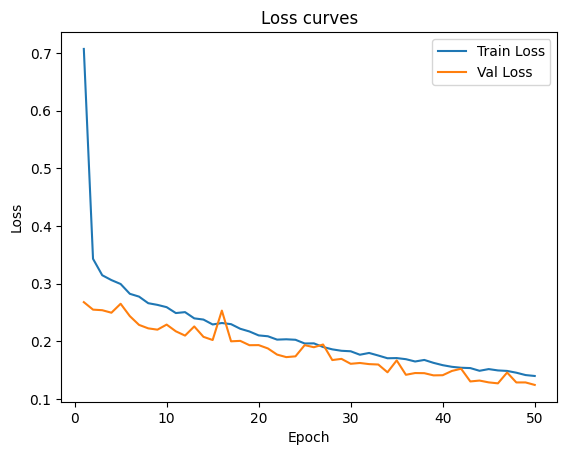

In [14]:
# Re-initialize model with Dropout (default 0.3)
model = BaselineNet(input_features=input_features, dropout_rate=0.3)

# Using HuberLoss instead of MSELoss to be more robust to outliers
loss_fn = nn.HuberLoss(delta=1.0)
# Increased learning rate to 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Retrain the model with Huber Loss
history = fit(model, train_loader, validation_loader, loss_fn, optimizer, device, epochs=50)

plot_history(history)

### Training the Deeper Neural Network
We'll now train the `DeepNet` model to see if the extra layers and Batch Normalization improve our regression performance.

Epoch: 1: Train loss: 0.8144, Val Loss: 0.3283
Epoch: 2: Train loss: 0.3809, Val Loss: 0.2728
Epoch: 3: Train loss: 0.3379, Val Loss: 0.3005
Epoch: 4: Train loss: 0.3101, Val Loss: 0.2308
Epoch: 5: Train loss: 0.2941, Val Loss: 0.3341
Epoch: 6: Train loss: 0.2875, Val Loss: 0.2181
Epoch: 7: Train loss: 0.2643, Val Loss: 0.2045
Epoch: 8: Train loss: 0.2489, Val Loss: 0.2653
Epoch: 9: Train loss: 0.2415, Val Loss: 0.1884
Epoch: 10: Train loss: 0.2255, Val Loss: 0.2086
Epoch: 11: Train loss: 0.2157, Val Loss: 0.1936
Epoch: 12: Train loss: 0.2045, Val Loss: 0.1649
Epoch: 13: Train loss: 0.1995, Val Loss: 0.1714
Epoch: 14: Train loss: 0.1956, Val Loss: 0.1597
Epoch: 15: Train loss: 0.1796, Val Loss: 0.1544
Epoch: 16: Train loss: 0.1795, Val Loss: 0.1504
Epoch: 17: Train loss: 0.1694, Val Loss: 0.1461
Epoch: 18: Train loss: 0.1679, Val Loss: 0.1429
Epoch: 19: Train loss: 0.1651, Val Loss: 0.1658
Epoch: 20: Train loss: 0.1470, Val Loss: 0.1550
Epoch: 21: Train loss: 0.1495, Val Loss: 0.1554
E

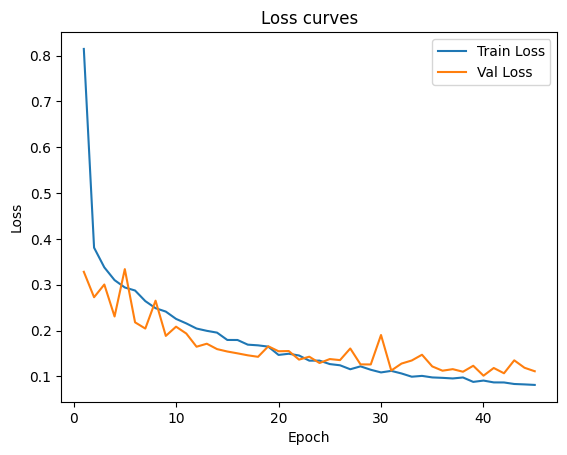

In [19]:
# Initialize the deeper model
deep_model = DeepNet(input_features=input_features, dropout_rate=0.3)

loss_fn = nn.HuberLoss(delta=1.0)
optimizer = torch.optim.Adam(deep_model.parameters(), lr=0.001)

# Train DeepNet
deep_history = fit(deep_model, train_loader, validation_loader, loss_fn, optimizer, device, epochs=50)

plot_history(deep_history)

# Evaluation: Build accuracy, f1, precision, and recall scores

In [20]:
def evaluate_model(model, loader, device):
    model.eval()
    all_predictions = []
    all_true_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            predictions = model(X_batch)

            all_predictions.extend(predictions.cpu().numpy().flatten())
            all_true_labels.extend(y_batch.cpu().numpy().flatten())

    # Calculate regression metrics
    mae = mean_absolute_error(all_true_labels, all_predictions)
    rmse = np.sqrt(mean_squared_error(all_true_labels, all_predictions))
    r2 = r2_score(all_true_labels, all_predictions)

    print(f"\nTest Set Evaluation:")
    print(f"  Mean Absolute Error (MAE): {mae:.4f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"  R-squared (R2): {r2:.4f}")

    return mae, rmse, r2


In [21]:
print("Evaluating model on the test set...")
model_mae, model_rmse, model_r2 = evaluate_model(model, test_loader, device)

Evaluating model on the test set...

Test Set Evaluation:
  Mean Absolute Error (MAE): 0.3597
  Root Mean Squared Error (RMSE): 0.5008
  R-squared (R2): 0.6988


In [22]:
print("Evaluating deep_model on the test set...")
deep_model_mae, deep_model_rmse, deep_model_r2 = evaluate_model(deep_model, test_loader, device)

Evaluating deep_model on the test set...

Test Set Evaluation:
  Mean Absolute Error (MAE): 0.3266
  Root Mean Squared Error (RMSE): 0.4786
  R-squared (R2): 0.7249


## Select Baseline or Deep NN

The Deep NN seems to capture the more complex patterns for affecting rankings better, so we go with the `deep_model`

In [64]:
# Experiment with predictions with the model OR the deeper version of the model
model = deep_model

## Testing Predictions

In [65]:
model.eval()
num_predictions = 5

print(f"\nMaking {num_predictions} one-off predictions from the test set:")
for i in range(num_predictions):
    # Get a sample from the test_dataset
    sample_input, sample_target = test_dataset[i]

    # Move to the correct device and make a prediction
    sample_input = sample_input.unsqueeze(0).to(device) # Add batch dimension
    with torch.no_grad():
        prediction = model(sample_input)

    # Print the true value and the predicted value
    print(f"Sample {i+1}: True rating = {sample_target.item():.2f}, Predicted rating = {prediction.item():.2f}")


Making 5 one-off predictions from the test set:
Sample 1: True rating = 6.36, Predicted rating = 5.41
Sample 2: True rating = 6.51, Predicted rating = 6.82
Sample 3: True rating = 5.45, Predicted rating = 5.32
Sample 4: True rating = 6.54, Predicted rating = 6.22
Sample 5: True rating = 5.82, Predicted rating = 5.65


In [66]:
def predict_with_mechanics(model, scaler, mlb_category, mlb_mechanic, categories_list, mechanics_list, original_numerical_means, feature_columns_names, device):
    model.eval()

    # Create a Series with all columns from X, initialized with float 0.0 to ensure float dtype
    sample_series = pd.Series(0.0, index=feature_columns_names)

    # Fill numerical columns with mean values from the training data
    # original_numerical_means is a Series whose index are the numerical column names
    for col in original_numerical_means.index:
        if col in sample_series.index:
            sample_series[col] = original_numerical_means[col]

    # Transform the input categories list using the fitted mlb_category
    categories_transformed = mlb_category.transform([categories_list])
    categories_cols = mlb_category.classes_

    # Update the sample_series with the transformed categories (1.0 for present, 0.0 for absent)
    for i, col_val in enumerate(categories_transformed[0]):
        if col_val == 1 and f'category_{categories_cols[i]}' in sample_series.index:
            sample_series[f'category_{categories_cols[i]}'] = 1.0

    # Transform the input mechanics list using the fitted mlb_mechanic
    mechanics_transformed = mlb_mechanic.transform([mechanics_list])
    mechanics_cols = mlb_mechanic.classes_

    # Update the sample_series with the transformed mechanics (1.0 for present, 0.0 for absent)
    for i, col_val in enumerate(mechanics_transformed[0]):
        if col_val == 1 and f'mechanic_{mechanics_cols[i]}' in sample_series.index:
            sample_series[f'mechanic_{mechanics_cols[i]}'] = 1.0

    # Convert the Series to a DataFrame
    sample_df = pd.DataFrame([sample_series])

    # Select only the numerical columns for scaling
    # The numerical columns for scaling are the index of original_numerical_means
    numerical_cols_for_scaling = original_numerical_means.index
    sample_df[numerical_cols_for_scaling] = scaler.transform(sample_df[numerical_cols_for_scaling])

    # Convert to PyTorch tensor
    sample_tensor = torch.tensor(sample_df.values, dtype=torch.float32).to(device)

    with torch.no_grad():
        prediction = model(sample_tensor)

    return prediction.item()


In [67]:
# Get the list of numerical columns that exist in the original X dataframe
numerical_cols_in_x_train = X.select_dtypes(include=np.number).columns

# Calculate mean of numerical columns from the original (unscaled) X for filling defaults
X_numerical_original = df_processed[numerical_cols_in_x_train].copy()
original_numerical_means = X_numerical_original.mean()

# Example usage with sample categories and mechanics
sample_categories_1 = ['Economic', 'Negotiation']
sample_mechanics_1 = ['Dice Rolling', 'Hand Management', 'Set Collection']
predicted_rating_1 = predict_with_mechanics(model, scaler, mlb_category, mlb_mechanic, sample_categories_1, sample_mechanics_1, original_numerical_means, X.columns, device)
print(f"Predicted rating for categories {sample_categories_1} and mechanics {sample_mechanics_1}: {predicted_rating_1:.2f}")

sample_categories_2 = ['Medical']
sample_mechanics_2 = ['Cooperative Game', 'Area Majority / Influence', 'Variable Player Powers']
predicted_rating_2 = predict_with_mechanics(model, scaler, mlb_category, mlb_mechanic, sample_categories_2, sample_mechanics_2, original_numerical_means, X.columns, device)
print(f"Predicted rating for categories {sample_categories_2} and mechanics {sample_mechanics_2}: {predicted_rating_2:.2f}")

# Example with only mechanics, defaulting categories to their mean (empty list)
sample_mechanics_3 = ['Tile Placement', 'Pattern Building']
predicted_rating_3 = predict_with_mechanics(model, scaler, mlb_category, mlb_mechanic, [], sample_mechanics_3, original_numerical_means, X.columns, device)
print(f"Predicted rating for only mechanics {sample_mechanics_3}: {predicted_rating_3:.2f}")

Predicted rating for categories ['Economic', 'Negotiation'] and mechanics ['Dice Rolling', 'Hand Management', 'Set Collection']: 6.04
Predicted rating for categories ['Medical'] and mechanics ['Cooperative Game', 'Area Majority / Influence', 'Variable Player Powers']: 6.42
Predicted rating for only mechanics ['Tile Placement', 'Pattern Building']: 6.08


### Exploring impact of mechanics on predicted ratings for high-rated games

In [68]:
print("\n--- Analysis of High-Rated Games with Modified Mechanics ---")

# Helper function to parse list-like strings, similar to the one used in preprocessing
def parse_list_string_for_prediction(s):
    if isinstance(s, str):
        try:
            return eval(s.replace("'", '"'))
        except (SyntaxError, TypeError):
            return []
    return []

# Get top rated games from the original DataFrame for reference
top_rated_games = df.sort_values(by='rating', ascending=False).head(5)

print(f"\nTop 5 original games by rating:\n{top_rated_games[['name', 'rating']]}")

# Example 1: Gloomhaven (Highest rated in our sample)
game_name_1 = 'Gloomhaven'
game_data_1 = df[df['name'] == game_name_1].iloc[0]
original_categories_1 = parse_list_string_for_prediction(game_data_1['boardgamecategory'])
original_mechanics_1 = parse_list_string_for_prediction(game_data_1['boardgamemechanic'])

predicted_original_1 = predict_with_mechanics(
    model, scaler, mlb_category, mlb_mechanic,
    original_categories_1, original_mechanics_1,
    original_numerical_means, X.columns, device
)

# Modify: Remove 'Storytelling' mechanic
modified_mechanics_1 = [m for m in original_mechanics_1 if m != 'Storytelling']
predicted_modified_1 = predict_with_mechanics(
    model, scaler, mlb_category, mlb_mechanic,
    original_categories_1, modified_mechanics_1,
    original_numerical_means, X.columns, device
)

print(f"\nGame: {game_name_1} (Original Rating: {game_data_1['rating']:.2f})")
print(f"  Original Prediction: {predicted_original_1:.2f} (Mechanics: {original_mechanics_1})")
print(f"  Modified Prediction: {predicted_modified_1:.2f} (Mechanics: {modified_mechanics_1}) (Removed 'Storytelling')")

# Example 2: Brass: Birmingham
game_name_2 = 'Brass: Birmingham'
game_data_2 = df[df['name'] == game_name_2].iloc[0]
original_categories_2 = parse_list_string_for_prediction(game_data_2['boardgamecategory'])
original_mechanics_2 = parse_list_string_for_prediction(game_data_2['boardgamemechanic'])

predicted_original_2 = predict_with_mechanics(
    model, scaler, mlb_category, mlb_mechanic,
    original_categories_2, original_mechanics_2,
    original_numerical_means, X.columns, device
)

# Modify: Add 'Dice Rolling' mechanic
modified_mechanics_2 = original_mechanics_2 + ['Dice Rolling']
predicted_modified_2 = predict_with_mechanics(
    model, scaler, mlb_category, mlb_mechanic,
    original_categories_2, modified_mechanics_2,
    original_numerical_means, X.columns, device
)

print(f"\nGame: {game_name_2} (Original Rating: {game_data_2['rating']:.2f})")
print(f"  Original Prediction: {predicted_original_2:.2f} (Mechanics: {original_mechanics_2})")
print(f"  Modified Prediction: {predicted_modified_2:.2f} (Mechanics: {modified_mechanics_2}) (Added 'Dice Rolling')")

# Example 3: Ark Nova
game_name_3 = 'Ark Nova'
game_data_3 = df[df['name'] == game_name_3].iloc[0]
original_categories_3 = parse_list_string_for_prediction(game_data_3['boardgamecategory'])
original_mechanics_3 = parse_list_string_for_prediction(game_data_3['boardgamemechanic'])

predicted_original_3 = predict_with_mechanics(
    model, scaler, mlb_category, mlb_mechanic,
    original_categories_3, original_mechanics_3,
    original_numerical_means, X.columns, device
)

# Modify: Remove 'Hexagon Grid' mechanic
modified_mechanics_3 = [m for m in original_mechanics_3 if m != 'Hexagon Grid']
predicted_modified_3 = predict_with_mechanics(
    model, scaler, mlb_category, mlb_mechanic,
    original_categories_3, modified_mechanics_3,
    original_numerical_means, X.columns, device
)

print(f"\nGame: {game_name_3} (Original Rating: {game_data_3['rating']:.2f})")
print(f"  Original Prediction: {predicted_original_3:.2f} (Mechanics: {original_mechanics_3})")
print(f"  Modified Prediction: {predicted_modified_3:.2f} (Mechanics: {modified_mechanics_3}) (Removed 'Hexagon Grid')")


--- Analysis of High-Rated Games with Modified Mechanics ---

Top 5 original games by rating:
                                                  name   rating
27168                             Aprendices de Druida  9.83871
27490                                    Match'n Lock!  9.68333
15746                            The Cones of Dunshire  9.55918
23070  Shadows of Brimstone: The Impossible Hell Train  9.49333
23193                               Eldfall Chronicles  9.46444

Game: Gloomhaven (Original Rating: 8.57)
  Original Prediction: 7.04 (Mechanics: ['Action Queue', 'Action Retrieval', 'Campaign / Battle Card Driven', 'Card Play Conflict Resolution', 'Communication Limits', 'Cooperative Game', 'Critical Hits and Failures', 'Deck Construction', 'Grid Movement', 'Hand Management', 'Hexagon Grid', 'Legacy Game', 'Line of Sight', 'Modular Board', 'Multi-Use Cards', 'Narrative Choice / Paragraph', 'Once-Per-Game Abilities', 'Role Playing', 'Scenario / Mission / Campaign Game', 'Simulta

In [69]:
def analyze_mechanic_sensitivity(df, model, mechanic_to_toggle, mode='add', num_games=20):
    """
    Generalizes the mechanic impact analysis for a batch of games.

    Args:
        df: The original dataframe containing game info.
        model: The trained neural network.
        mechanic_to_toggle: The string name of the mechanic to add or remove.
        mode: 'add' to add the mechanic, 'remove' to remove it.
        num_games: Number of games to analyze (sampled from top ratings).
    """
    # Use top rated games for analysis
    sample_games = df.sort_values(by='rating', ascending=False).head(num_games)

    results = []

    for _, game in sample_games.iterrows():
        cats = parse_list_string_for_prediction(game['boardgamecategory'])
        mechs = parse_list_string_for_prediction(game['boardgamemechanic'])

        # Original Prediction
        pred_before = predict_with_mechanics(
            model, scaler, mlb_category, mlb_mechanic,
            cats, mechs, original_numerical_means, X.columns, device
        )

        # Modified Prediction
        if mode == 'add':
            new_mechs = list(set(mechs + [mechanic_to_toggle]))
        else:
            new_mechs = [m for m in mechs if m != mechanic_to_toggle]

        pred_after = predict_with_mechanics(
            model, scaler, mlb_category, mlb_mechanic,
            cats, new_mechs, original_numerical_means, X.columns, device
        )

        diff = pred_after - pred_before
        results.append({
            'Name': game['name'][:20],
            'Before': pred_before,
            'After': pred_after,
            'Diff': diff
        })

    # Concise Printing
    print(f"--- Impact Analysis: {mode.upper()}ing '{mechanic_to_toggle}' ---")
    print(f"{'Game Name':<22} | {'Before':<7} | {'After':<7} | {'Change':<7}")
    print("-" * 55)
    for r in results:
        sign = "+" if r['Diff'] > 0 else ""
        print(f"{r['Name']:<22} | {r['Before']:.3f}   | {r['After']:.3f}   | {sign}{r['Diff']:.3f}")

# Example usage: Adding 'Dice Rolling' to the top 20 games
analyze_mechanic_sensitivity(df, model, 'Dice Rolling', mode='add', num_games=20)

--- Impact Analysis: ADDing 'Dice Rolling' ---
Game Name              | Before  | After   | Change 
-------------------------------------------------------
Aprendices de Druida   | 8.058   | 8.046   | -0.012
Match'n Lock!          | 7.296   | 7.370   | +0.075
The Cones of Dunshir   | 6.303   | 6.283   | -0.020
Shadows of Brimstone   | 8.032   | 8.032   | 0.000
Eldfall Chronicles     | 8.106   | 8.106   | 0.000
Die Festung Hamburg    | 6.379   | 6.379   | 0.000
TerroriXico            | 6.743   | 6.716   | -0.027
Shadows of Brimstone   | 7.176   | 7.176   | 0.000
Parks & Potions        | 7.688   | 7.688   | 0.000
The Hunters A. D. 14   | 6.689   | 6.675   | -0.014
Lost in the Shuffle    | 6.155   | 6.140   | -0.015
1985: Sacred Oil       | 6.629   | 6.629   | 0.000
Blooming Field         | 6.693   | 6.681   | -0.012
Meeple Quest           | 6.807   | 6.807   | 0.000
Artefacts              | 8.672   | 8.670   | -0.001
NEON HOPE              | 8.676   | 8.677   | +0.001
Gladiatoris        

### Validation of Game Mechanics
In this section, we verify that the unique mechanics extracted from the dataset are valid, distinct, and properly categorized. This ensures that the sensitivity analysis and prediction functions use high-quality, non-redundant feature data.

In [70]:
# Retrieve the full list of unique mechanics from the fitted MultiLabelBinarizer
all_mechanics = sorted(mlb_mechanic.classes_)

print(f"Total unique mechanics detected: {len(all_mechanics)}\n")

# Printing them in a readable format (columns)
import math
cols = 3
rows = math.ceil(len(all_mechanics) / cols)

for i in range(rows):
    row_mechanics = all_mechanics[i::rows]
    print("".join(f"{mech:<40}" for mech in row_mechanics))

Total unique mechanics detected: 191

Acting                                  Hand Management                         Race                                    
Action / Event                          Hexagon Grid                            Random Production                       
Action Drafting                         Hidden Movement                         Ratio / Combat Results Table            
Action Points                           Hidden Roles                            Re-rolling and Locking                  
Action Queue                            Hidden Victory Points                   Real-Time                               
Action Retrieval                        Highest-Lowest Scoring                  Relative Movement                       
Action Timer                            Hot Potato                              Resource Queue                          
Advantage Token                         I Cut, You Choose                       Resource to Move                   

In [71]:
import difflib

# Group mechanics by common prefixes or keywords
groups = {
    'Auction': [m for m in all_mechanics if 'Auction' in m],
    'Turn Order': [m for m in all_mechanics if 'Turn Order' in m],
    'Worker Placement': [m for m in all_mechanics if 'Worker Placement' in m],
    'Movement': [m for m in all_mechanics if 'Movement' in m],
    'Grid': [m for m in all_mechanics if 'Grid' in m],
    'Dice': [m for m in all_mechanics if 'Dice' in m]
}

print("--- Potential Semantic Clusters ---")
for group_name, members in groups.items():
    if len(members) > 1:
        print(f"\n{group_name} ({len(members)} variations):")
        print(", ".join(members))

# Use fuzzy matching to find strings that are nearly identical (typos or naming variations)
print("\n--- Highly Similar Strings (Potential Duplicates) ---")
found_similar = False
for i, mech in enumerate(all_mechanics):
    matches = difflib.get_close_matches(mech, all_mechanics[i+1:], n=1, cutoff=0.85)
    if matches:
        print(f"'{mech}' is very similar to '{matches[0]}'")
        found_similar = True

if not found_similar:
    print("No near-identical string duplicates found.")

--- Potential Semantic Clusters ---

Auction (13 variations):
Auction / Bidding, Auction Compensation, Auction: Dexterity, Auction: Dutch, Auction: Dutch Priority, Auction: English, Auction: Fixed Placement, Auction: Multiple Lot, Auction: Once Around, Auction: Sealed Bid, Auction: Turn Order Until Pass, Closed Economy Auction, Turn Order: Auction

Turn Order (9 variations):
Auction: Turn Order Until Pass, Turn Order: Auction, Turn Order: Claim Action, Turn Order: Pass Order, Turn Order: Progressive, Turn Order: Random, Turn Order: Role Order, Turn Order: Stat-Based, Turn Order: Time Track

Worker Placement (3 variations):
Worker Placement, Worker Placement with Dice Workers, Worker Placement, Different Worker Types

Movement (14 variations):
Area Movement, Different Dice Movement, Grid Movement, Hidden Movement, Impulse Movement, Measurement Movement, Movement Points, Movement Template, Pattern Movement, Point to Point Movement, Programmed Movement, Relative Movement, Three Dimensiona

### Board Game Category Analysis
This section lists all unique categories identified in the dataset and analyzes them for semantic overlap, ensuring our model's categorical features are well-understood.

In [73]:
# Retrieve and display the full list of unique board game categories
all_categories = sorted(mlb_category.classes_)

print(f"Total unique categories detected: {len(all_categories)}\n")

# Print categories in a readable 3-column format
import math
cols = 3
rows = math.ceil(len(all_categories) / cols)

for i in range(rows):
    row_cats = all_categories[i::rows]
    print("".join(f"{cat:<40}" for cat in row_cats))

Total unique categories detected: 83

Abstract Strategy                       Fan Expansion                           Pike and Shot                           
Action / Dexterity                      Fantasy                                 Pirates                                 
Adventure                               Farming                                 Political                               
Age of Reason                           Fighting                                Post-Napoleonic                         
American Civil War                      Game System                             Prehistoric                             
American Indian Wars                    Horror                                  Print & Play                            
American Revolutionary War              Humor                                   Puzzle                                  
American West                           Industry / Manufacturing                Racing                             

In [74]:
# Retrieve the full list of unique categories
all_categories = sorted(mlb_category.classes_)

# Group categories by common keywords
cat_groups = {
    'War / Military': [c for c in all_categories if any(word in c for word in ['War', 'Civil War', 'Warfare'])],
    'History': [c for c in all_categories if any(word in c for word in ['Ancient', 'Medieval', 'Renaissance', 'Century'])],
    'Science / Nature': [c for c in all_categories if any(word in c for word in ['Science', 'Nature', 'Environmental', 'Space'])],
    'American History': [c for c in all_categories if 'American' in c]
}

print(f"Total unique categories detected: {len(all_categories)}\n")

print("--- Potential Category Semantic Clusters ---")
for group_name, members in cat_groups.items():
    if len(members) > 1:
        print(f"\n{group_name} ({len(members)} variations):")
        print(", ".join(members))

# Fuzzy matching for categories
print("\n--- Highly Similar Categories (Potential Duplicates) ---")
found_similar_cat = False
for i, cat in enumerate(all_categories):
    matches = difflib.get_close_matches(cat, all_categories[i+1:], n=1, cutoff=0.85)
    if matches:
        print(f"'{cat}' is very similar to '{matches[0]}'")
        found_similar_cat = True

if not found_similar_cat:
    print("No near-identical category duplicates found.")

Total unique categories detected: 83

--- Potential Category Semantic Clusters ---

War / Military (10 variations):
American Civil War, American Indian Wars, American Revolutionary War, Civil War, Korean War, Modern Warfare, Vietnam War, Wargame, World War I, World War II

History (3 variations):
Ancient, Medieval, Renaissance

Science / Nature (3 variations):
Environmental, Science Fiction, Space Exploration

American History (4 variations):
American Civil War, American Indian Wars, American Revolutionary War, American West

--- Highly Similar Categories (Potential Duplicates) ---
'World War I' is very similar to 'World War II'


## Saving model weights

In [75]:
import pickle
import torch

# 1. Save the PyTorch model weights
torch.save(model.state_dict(), 'boardgame_rating_model.pth')

# 2. Save the preprocessing objects (Scaler and Binarizers)
preprocessing_assets = {
    'scaler': scaler,
    'mlb_category': mlb_category,
    'mlb_mechanic': mlb_mechanic,
    'original_numerical_means': original_numerical_means,
    'feature_names': X.columns.tolist()
}

with open('preprocessing_assets.pkl', 'wb') as f:
    pickle.dump(preprocessing_assets, f)

print("Model weights saved to: boardgame_rating_model.pth")
print("Preprocessing assets saved to: preprocessing_assets.pkl")

Model weights saved to: boardgame_rating_model.pth
Preprocessing assets saved to: preprocessing_assets.pkl


### How to Download to your local machine
You can find these files in the file browser on the left sidebar (folder icon).

To download them via code, run the following cell:

In [76]:
from google.colab import files

files.download('boardgame_rating_model.pth')
files.download('preprocessing_assets.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Deployment Example: FastAPI Integration

To serve this model, you can use a FastAPI server. The code below demonstrates how to load the model and assets to create a `/predict` endpoint.

In [ ]:
# This is a conceptual example for a separate deployment script (e.g., app.py)
# You would need to install fastapi and uvicorn: pip install fastapi uvicorn

import torch
import pickle
import pandas as pd
from fastapi import FastAPI
from pydantic import BaseModel
from typing import List

app = FastAPI(title="Board Game Rating Predictor")

# --- Initialization Logic ---
# 1. Load Preprocessing Assets
with open('preprocessing_assets.pkl', 'rb') as f:
    assets = pickle.load(f)

scaler = assets['scaler']
mlb_category = assets['mlb_category']
mlb_mechanic = assets['mlb_mechanic']
original_numerical_means = assets['original_numerical_means']
feature_names = assets['feature_names']

# 2. Reconstruct Model and Load Weights
# Note: Ensure DeepNet class definition is imported or defined here
input_dim = len(feature_names)
model = DeepNet(input_features=input_dim) # Use the class defined earlier
model.load_state_dict(torch.load('boardgame_rating_model.pth', map_location=torch.device('cpu')))
model.eval()

class GameInput(BaseModel):
    categories: List[str]
    mechanics: List[str]

@app.post("/predict")
def predict_rating(game: GameInput):
    # Re-use the logic from our predict_with_mechanics function
    sample_series = pd.Series(0.0, index=feature_names)

    # Fill numerical defaults
    for col in original_numerical_means.index:
        if col in sample_series.index:
            sample_series[col] = original_numerical_means[col]

    # One-hot encoding
    cats_encoded = mlb_category.transform([game.categories])
    mechs_encoded = mlb_mechanic.transform([game.mechanics])

    for i, val in enumerate(cats_encoded[0]):
        if val == 1 and f'category_{mlb_category.classes_[i]}' in sample_series.index:
            sample_series[f'category_{mlb_category.classes_[i]}'] = 1.0

    for i, val in enumerate(mechs_encoded[0]):
        if val == 1 and f'mechanic_{mlb_mechanic.classes_[i]}' in sample_series.index:
            sample_series[f'mechanic_{mlb_mechanic.classes_[i]}'] = 1.0

    # Scale and Predict
    sample_df = pd.DataFrame([sample_series])
    num_cols = original_numerical_means.index
    sample_df[num_cols] = scaler.transform(sample_df[num_cols])

    sample_tensor = torch.tensor(sample_df.values, dtype=torch.float32)
    with torch.no_grad():
        pred = model(sample_tensor).item()

    return {"predicted_rating": round(pred, 2)}

print("FastAPI app logic ready. In a terminal, run: uvicorn app:app --reload")